In [1]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

print(nav.head())


   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639


In [2]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [3]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [4]:
cagr_results = []

for code, group in nav.groupby("amfi_code"):

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        group["date"].max()
        -
        group["date"].min()
    ).days / 365

    cagr = (
        (end_nav/start_nav)
        **
        (1/years)
        - 1
    ) * 100

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_pct"
    ]
)

cagr_df.head()

,amfi_code,cagr_pct
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [5]:
cagr_df.to_csv(
    "../data/processed/cagr.csv",
    index=False
)

print("CAGR saved")

CAGR saved


In [6]:
import numpy as np

rf = 0.065

sharpe_list = []

for code, group in nav.groupby("amfi_code"):

    r = group["daily_return"].dropna()

    sharpe = (
        ((r.mean()*252) - rf)
        /
        r.std()
    ) * np.sqrt(252)

    sharpe_list.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-50.782301
1,100025,-142.907888
2,100033,275.612083
3,101206,258.857759
4,101207,40.990514


In [7]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio saved")

Sharpe Ratio saved


In [8]:
sortino_list = []

for code, group in nav.groupby("amfi_code"):

    r = group["daily_return"].dropna()

    downside = r[r < 0]

    sortino = (
        ((r.mean()*252)-0.065)
        /
        downside.std()
    ) * np.sqrt(252)

    sortino_list.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-88.463960
1,100025,-237.338952
2,100033,460.941758
3,101206,453.489844
4,101207,69.714237


In [9]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio saved")

Sortino Ratio saved


In [10]:
dd_list = []

for code, group in nav.groupby("amfi_code"):

    running_max = group["nav"].cummax()

    drawdown = (
        group["nav"] / running_max
    ) - 1

    dd_list.append(
        [code, drawdown.min()]
    )

dd_df = pd.DataFrame(
    dd_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [11]:
dd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("Max Drawdown saved")

Max Drawdown saved


In [12]:
from scipy.stats import linregress

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark[
    benchmark["index_name"] == "NIFTY100"
]

benchmark["benchmark_return"] = (
    benchmark["close_value"]
    .pct_change()
)

results = []

for code, group in nav.groupby("amfi_code"):

    merged = pd.merge(
        group,
        benchmark,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 20:

        slope, intercept, r, p, se = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        results.append([
            code,
            intercept * 252,
            slope
        ])

alpha_beta = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [13]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha Beta saved")

Alpha Beta saved


In [14]:
cagr_df = pd.read_csv("../data/processed/cagr.csv")
sharpe_df = pd.read_csv("../data/processed/sharpe_ratio.csv")
dd_df = pd.read_csv("../data/processed/max_drawdown.csv")
alpha_beta = pd.read_csv("../data/processed/alpha_beta.csv")

scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(alpha_beta, on="amfi_code")
    .merge(dd_df, on="amfi_code")
)

scorecard["score"] = (
    scorecard["cagr_pct"].rank(pct=True) * 30
    + scorecard["sharpe_ratio"].rank(pct=True) * 25
    + scorecard["alpha"].rank(pct=True) * 20
    + scorecard["max_drawdown"].rank(
        ascending=False,
        pct=True
      ) * 25
)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.head()

,amfi_code,cagr_pct,sharpe_ratio,alpha,beta,max_drawdown,score
39,149324,32.262108,239.348548,0.300579,0.011455,-0.311719,88.625
21,119598,32.398084,238.217681,0.303370,-0.023196,-0.287060,88.625
25,120505,32.801599,297.385502,0.292636,0.000549,-0.181885,87.125
36,148569,31.924486,311.202366,0.282704,0.018134,-0.163967,83.125
38,149323,29.558105,285.294707,0.265986,-0.002523,-0.172481,76.875


In [15]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved")

Fund Scorecard saved


Matplotlib is building the font cache; this may take a moment.


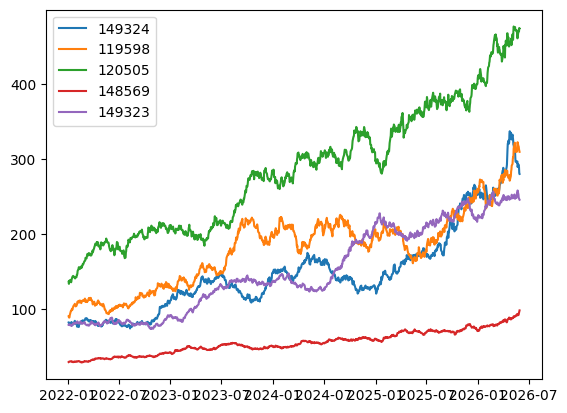

In [16]:
import matplotlib.pyplot as plt

top5 = scorecard.head(5)

for code in top5["amfi_code"]:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png"
)

plt.show()